### Импорт библиотек

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

import ssl
import urllib

### Загрузка и предобработка данных

In [22]:
ssl._create_default_https_context = ssl._create_unverified_context
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
ssl._create_default_https_context = ssl.create_default_context

print(f"Размер обучающей выборки: {x_train.shape}")
print(f"Размер тестовой выборки: {x_test.shape}")

Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)


In [ ]:
# Нормирование данных
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Добавляем ещё одно измерение (канал)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Разбиваем на категории (10 так как предсказываем цифры)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Разделение данных на тренировочную и валидационную выборки
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)

### Построение и обучение моделей

In [24]:
# Основная модель
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # Слой свертки
    layers.MaxPooling2D((2, 2)), # Пулинг слой. Для уменьшения размерности карты признаков

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(), # Преобразует двухмерную карту признаков в одномерный вектор

    layers.Dense(256, activation='relu'), # Полносвязный слой 

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,242 (1.65 MB)

 Trainable params: 431,242 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
# Базовая модель
base_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,242 (1.65 MB)

 Trainable params: 431,242 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
base_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
epochs = 15
batch_size = 128

In [29]:
history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9321 - loss: 0.2303 - val_accuracy: 0.9740 - val_loss: 0.0836
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9821 - loss: 0.0585 - val_accuracy: 0.9837 - val_loss: 0.0549
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9883 - loss: 0.0388 - val_accuracy: 0.9876 - val_loss: 0.0405
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9877 - val_loss: 0.0438
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9928 - loss: 0.0222 - val_accuracy: 0.9886 - val_loss: 0.0392
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9950 - loss: 0.0162 - val_accuracy: 0.9887 - val_loss: 0.0388
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9961 - loss: 0.0129 - val_accuracy: 0.9874 - val_loss: 0.0466
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9962 - loss: 0.0110 - val_accu

In [30]:
base_history = base_model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9182 - loss: 0.2874 - val_accuracy: 0.9721 - val_loss: 0.0937
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9793 - loss: 0.0691 - val_accuracy: 0.9823 - val_loss: 0.0599
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9848 - loss: 0.0498 - val_accuracy: 0.9858 - val_loss: 0.0501
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9863 - val_loss: 0.0464
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9910 - loss: 0.0298 - val_accuracy: 0.9875 - val_loss: 0.0431
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9925 - loss: 0.0232 - val_accuracy: 0.9872 - val_loss: 0.0421
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9942 - loss: 0.0189 - val_accuracy: 0.9886 - val_loss: 0.0393
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9951 - loss: 0.0160 - val_accu

### Построение графиков и оценка качества моделей

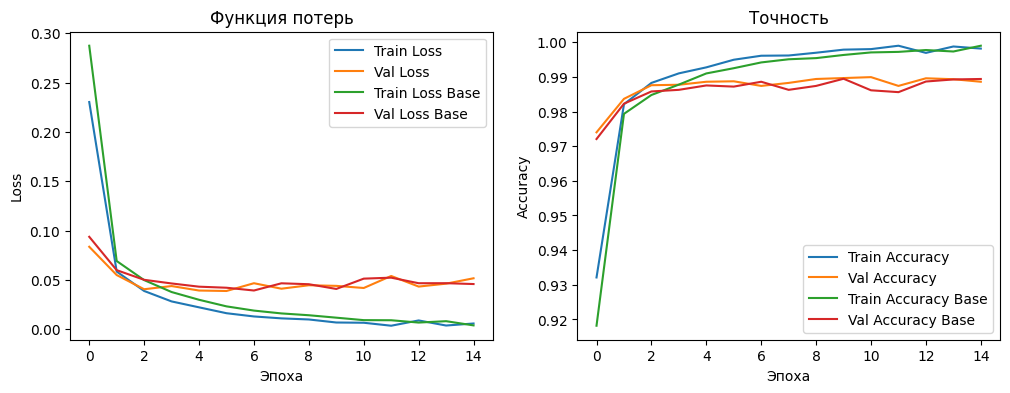

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График потери
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.plot(base_history.history['loss'], label='Train Loss Base')
ax1.plot(base_history.history['val_loss'], label='Val Loss Base')
ax1.set_title('Функция потерь')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.legend()

# График точности
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.plot(base_history.history['accuracy'], label='Train Accuracy Base')
ax2.plot(base_history.history['val_accuracy'], label='Val Accuracy Base')
ax2.set_title('Точность')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

In [32]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовом наборе: {test_acc:.4f}")

test_loss, test_acc = base_model.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовом наборе: {test_acc:.4f}")


Точность на тестовом наборе: 0.9903

Точность на тестовом наборе: 0.9913


#### Вывод
Судя по графикам и оценке, базовая и основная модели справились одинаково хорошо, и их точность достигла 99%

### Предсказание на тестовых данных

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Изображение 1: Предсказано = 7, Верно = 7


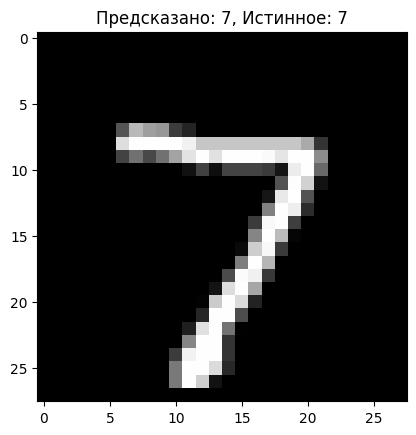

Изображение 2: Предсказано = 2, Верно = 2


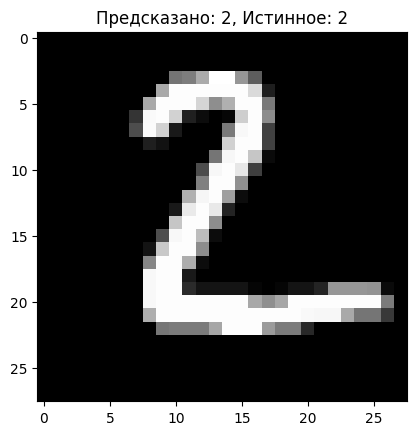

Изображение 3: Предсказано = 1, Верно = 1


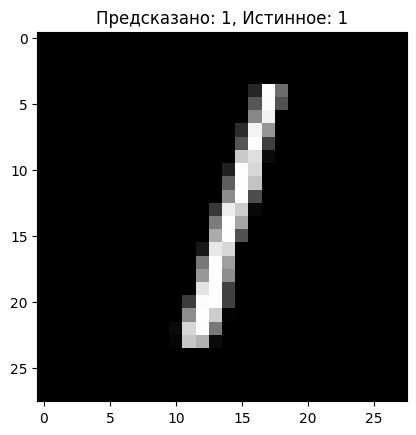

Изображение 4: Предсказано = 0, Верно = 0


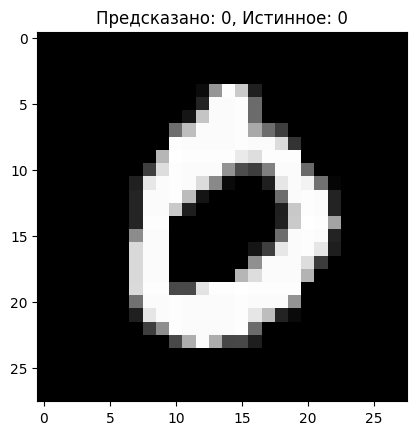

Изображение 5: Предсказано = 4, Верно = 4


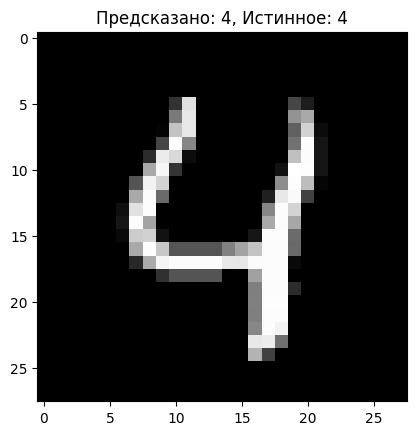

Изображение 6: Предсказано = 1, Верно = 1


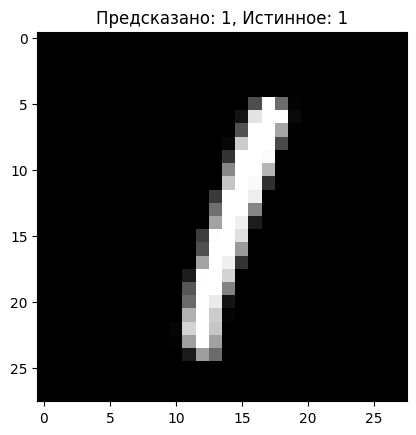

Изображение 7: Предсказано = 4, Верно = 4


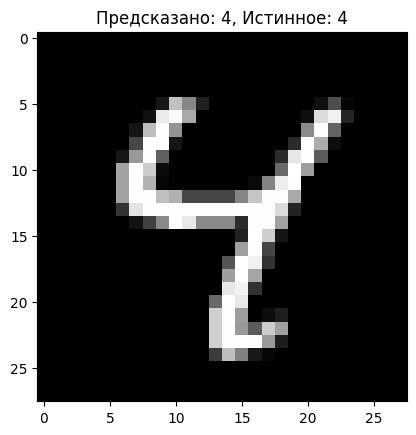

Изображение 8: Предсказано = 9, Верно = 9


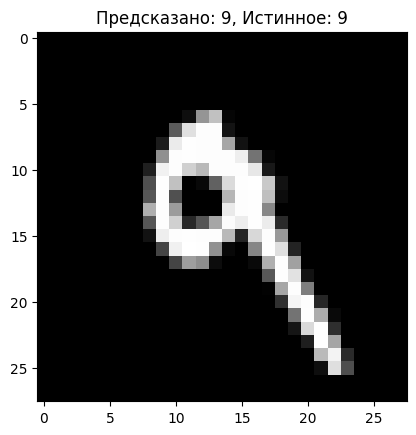

Изображение 9: Предсказано = 5, Верно = 5


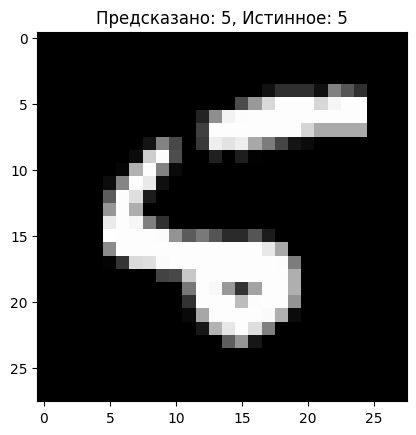

Изображение 10: Предсказано = 9, Верно = 9


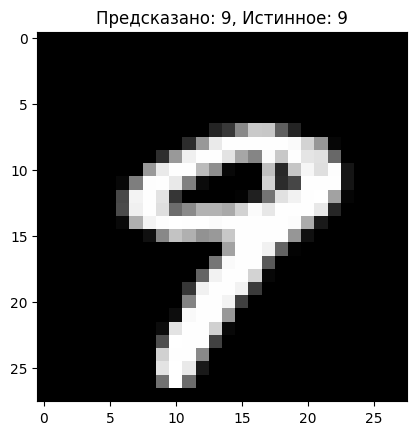

In [33]:
predictions = model.predict(x_test[:10])

for i in range(len(predictions)):
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(y_test[i])
    print(f"Изображение {i+1}: Предсказано = {predicted_label}, Верно = {true_label}")

    # Визуализация
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title(f"Предсказано: {predicted_label}, Истинное: {true_label}")
    plt.show()